# Lab Report 05 - Running Code

This notebook contains the full runnable practical for `Lab Report 05` with separate Python cells and explanatory comments.

In [1]:
# Import required libraries.
# cv2        -> image processing and filtering
# numpy      -> array operations and custom kernels
# matplotlib -> notebook-friendly image display
# pathlib    -> robust file path handling
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Search for the image in likely locations.
# The lab notes use 'girl.jpg', but your project root file is 'Girl.jpg'.
candidate_paths = [
    Path("Girl.jpg"),
    Path("girl.jpg"),
    Path("../Girl.jpg"),
    Path("../girl.jpg"),
    Path(r"C:/Users/kavin/OneDrive/Documents/Projects/Digital Image Processing and Computer Vision/Girl.jpg"),
]

image_path = next((path for path in candidate_paths if path.exists()), None)

if image_path is None:
    raise FileNotFoundError(
        "Could not find 'Girl.jpg' or 'girl.jpg'. Keep the image in the project root or current working directory."
    )

# Load the image in grayscale mode because all four filters in this lab use grayscale input.
image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

if image is None:
    raise ValueError(f"OpenCV could not read the image: {image_path}")

print(f"Loaded image from: {image_path.resolve()}")
print(f"Image shape: {image.shape}")
print(f"Data type: {image.dtype}")

Loaded image from: C:\Users\kavin\OneDrive\Documents\Projects\Digital Image Processing and Computer Vision\Girl.jpg
Image shape: (512, 512)
Data type: uint8


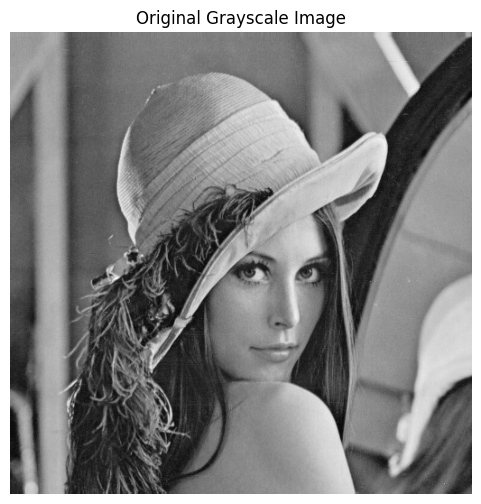

In [3]:
# Display the original grayscale image.
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

In [4]:
# Define a custom mean filter.
# Each output pixel becomes the average of its local neighborhood.
def mean_filter(image, kernel_size):
    padded_image = cv2.copyMakeBorder(
        image,
        kernel_size // 2,
        kernel_size // 2,
        kernel_size // 2,
        kernel_size // 2,
        cv2.BORDER_CONSTANT,
    )

    filtered_image = np.zeros_like(image)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            window = padded_image[y:y + kernel_size, x:x + kernel_size]
            filtered_image[y, x] = np.mean(window)

    return filtered_image

kernel_size = 5
mean_result = mean_filter(image, kernel_size)
print("Mean filter applied successfully.")

Mean filter applied successfully.


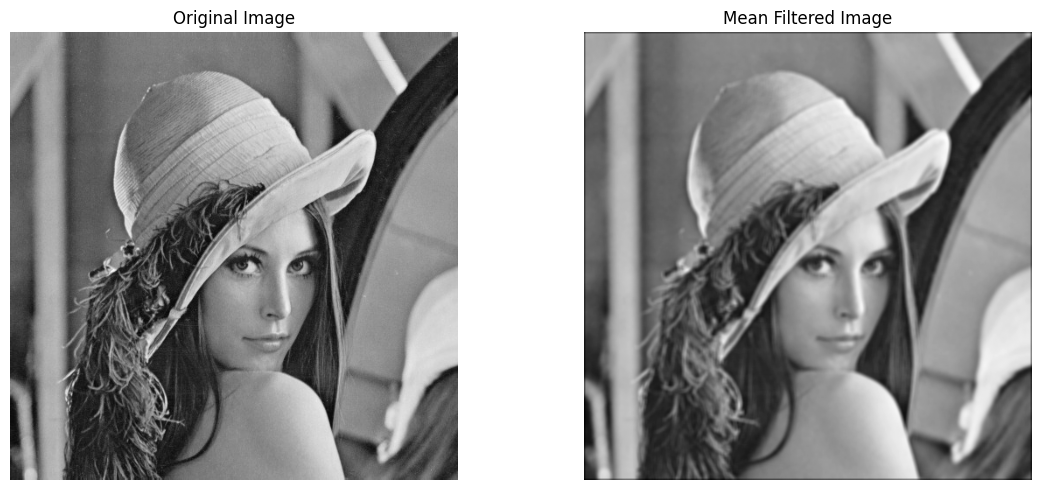

In [5]:
# Display the mean filtered result.
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mean_result, cmap="gray")
plt.title("Mean Filtered Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Define a function to create a Gaussian kernel.
# Pixels near the center receive larger weights than distant pixels.
def gaussian_kernel(size, sigma=1.0):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel

# Define a generic convolution function for grayscale images.
def convolve(image, kernel):
    pad = kernel.shape[0] // 2
    padded_image = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_CONSTANT)
    output = np.zeros_like(image, dtype=np.float32)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            window = padded_image[y:y + kernel.shape[0], x:x + kernel.shape[1]]
            output[y, x] = np.sum(window * kernel)

    return output.astype(np.uint8)

gaussian_size = 5
sigma = 1.0
g_kernel = gaussian_kernel(gaussian_size, sigma)
gaussian_result = convolve(image, g_kernel)

print("Gaussian filter applied successfully.")
print("Gaussian kernel:")
print(g_kernel)

Gaussian filter applied successfully.
Gaussian kernel:
[[0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.02193823 0.09832033 0.16210282 0.09832033 0.02193823]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]]


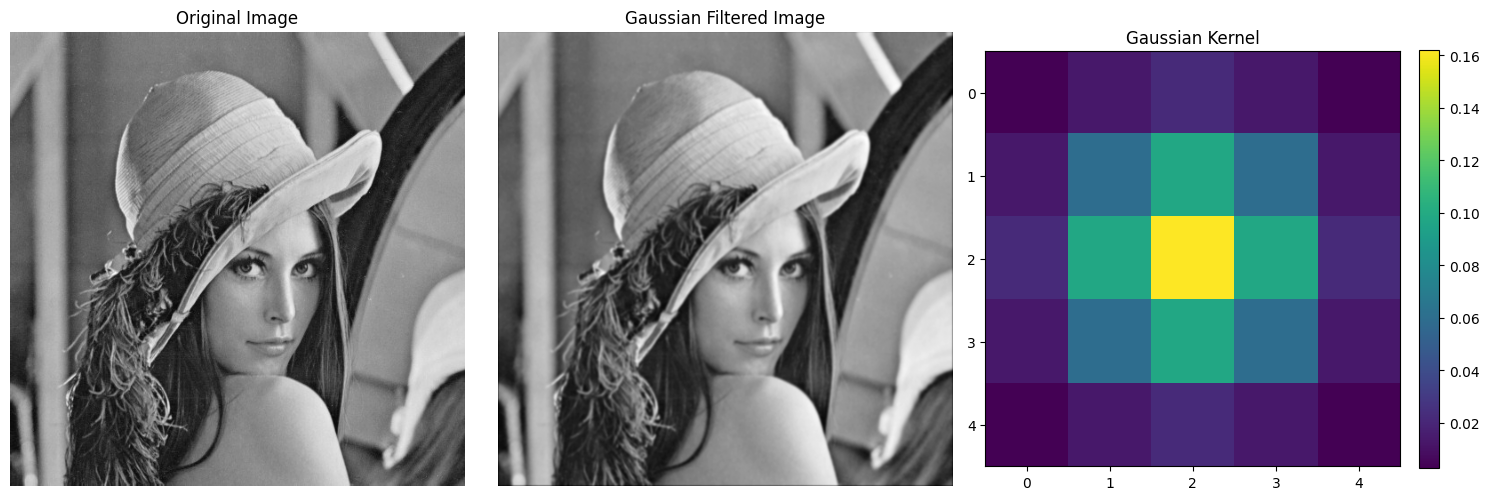

In [7]:
# Display the Gaussian filtered image and the kernel.
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gaussian_result, cmap="gray")
plt.title("Gaussian Filtered Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(g_kernel, cmap="viridis")
plt.title("Gaussian Kernel")
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [8]:
# Define Sobel kernels for x-direction and y-direction gradients.
# These kernels highlight edges by measuring intensity change.
sobel_x_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=np.float32)

sobel_y_kernel = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1],
], dtype=np.float32)

# Apply the Sobel kernels using filter2D.
sobel_x = cv2.filter2D(image, cv2.CV_64F, sobel_x_kernel)
sobel_y = cv2.filter2D(image, cv2.CV_64F, sobel_y_kernel)

# Combine x and y responses into one gradient magnitude image.
gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_result = cv2.normalize(gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX)
sobel_result = sobel_result.astype(np.uint8)

print("Sobel edge detection applied successfully.")

Sobel edge detection applied successfully.


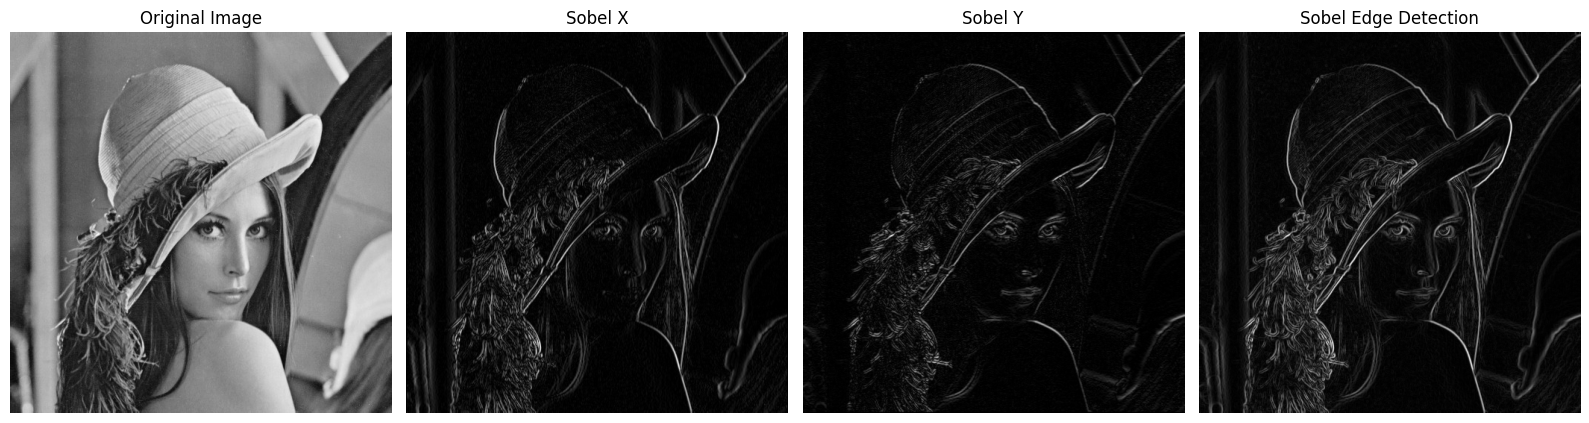

In [9]:
# Display Sobel edge detection results.
plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(np.abs(sobel_x), cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(np.abs(sobel_y), cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(sobel_result, cmap="gray")
plt.title("Sobel Edge Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# Define a custom median filter.
# The median filter is effective for removing salt-and-pepper noise.
def custom_median_filter(image, kernel_size):
    height, width = image.shape
    filtered_image = np.zeros_like(image)
    kernel_half = kernel_size // 2

    padded_image = cv2.copyMakeBorder(
        image,
        kernel_half,
        kernel_half,
        kernel_half,
        kernel_half,
        cv2.BORDER_CONSTANT,
    )

    for i in range(height):
        for j in range(width):
            window = []
            for ki in range(-kernel_half, kernel_half + 1):
                for kj in range(-kernel_half, kernel_half + 1):
                    window.append(padded_image[i + ki + kernel_half, j + kj + kernel_half])

            window.sort()
            filtered_image[i, j] = window[len(window) // 2]

    return filtered_image

median_result = custom_median_filter(image, 5)
print("Median filter applied successfully.")

Median filter applied successfully.


In [11]:
# Create salt-and-pepper style noise to demonstrate why the median filter is useful.
np.random.seed(7)
salt_pepper = image.copy()

num_pixels = image.size
num_salt = num_pixels // 50
num_pepper = num_pixels // 50

salt_coords = (
    np.random.randint(0, image.shape[0], num_salt),
    np.random.randint(0, image.shape[1], num_salt),
)
pepper_coords = (
    np.random.randint(0, image.shape[0], num_pepper),
    np.random.randint(0, image.shape[1], num_pepper),
)

salt_pepper[salt_coords] = 255
salt_pepper[pepper_coords] = 0

median_noisy_result = custom_median_filter(salt_pepper, 5)
print("Salt-and-pepper noise added and median filtering completed.")

Salt-and-pepper noise added and median filtering completed.


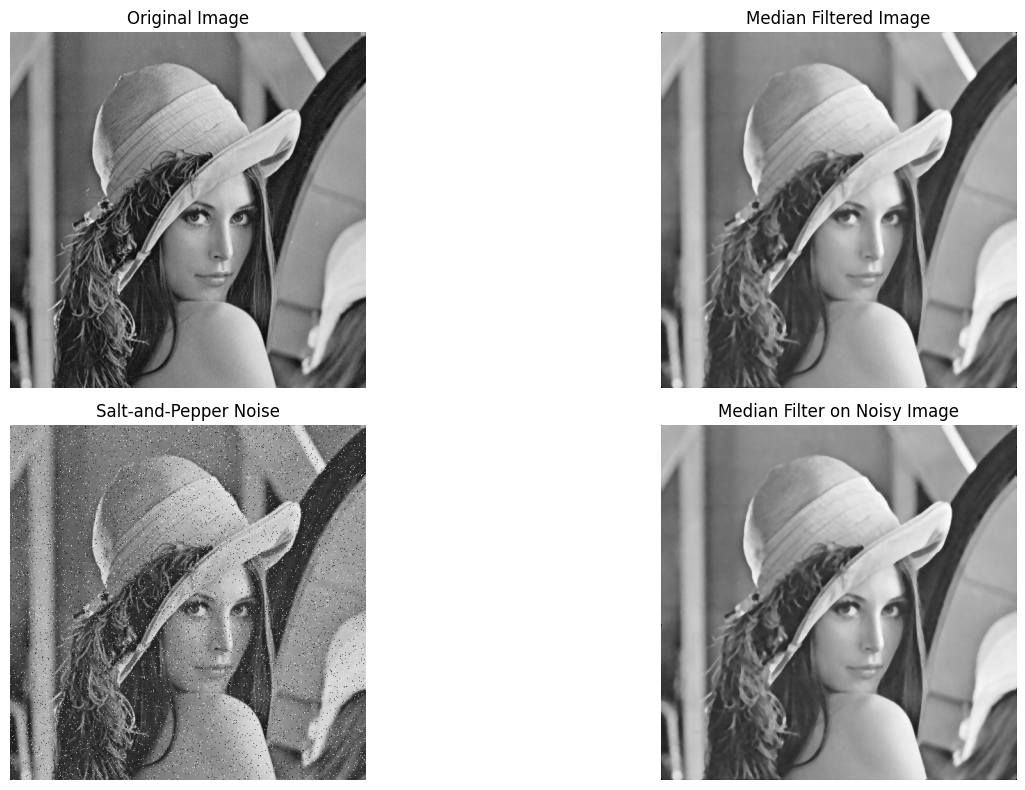

In [12]:
# Display the median filter effect on the original image and noisy image.
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(median_result, cmap="gray")
plt.title("Median Filtered Image")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(salt_pepper, cmap="gray")
plt.title("Salt-and-Pepper Noise")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(median_noisy_result, cmap="gray")
plt.title("Median Filter on Noisy Image")
plt.axis("off")

plt.tight_layout()
plt.show()

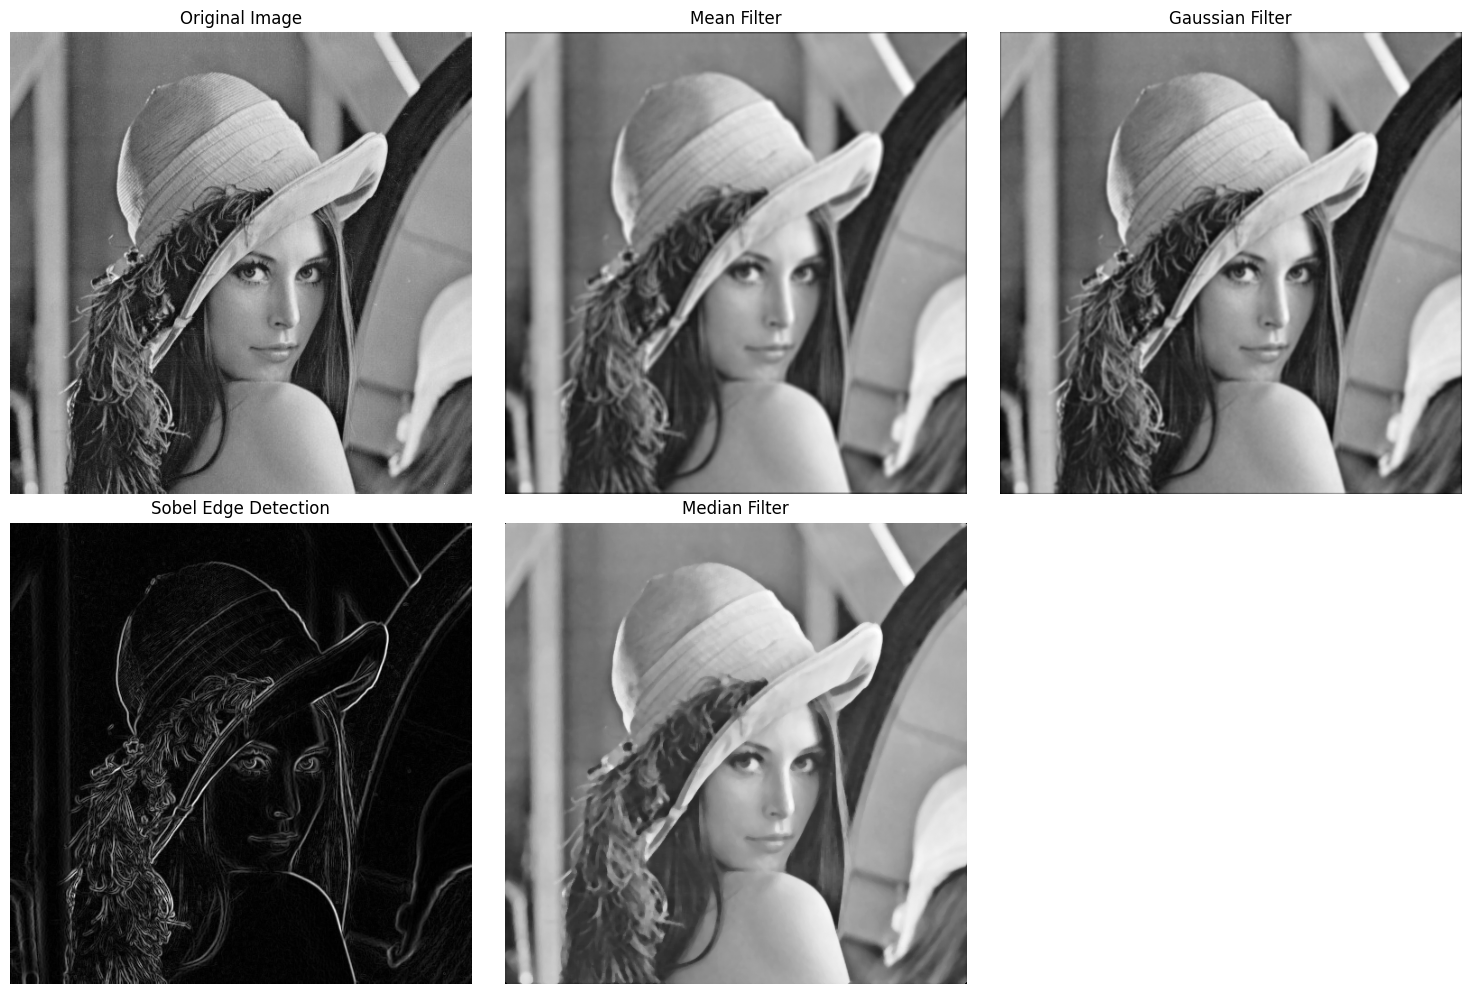

In [13]:
# Compare all four filter outputs in one figure.
plt.figure(figsize=(15, 10))

images = [image, mean_result, gaussian_result, sobel_result, median_result]
titles = [
    "Original Image",
    "Mean Filter",
    "Gaussian Filter",
    "Sobel Edge Detection",
    "Median Filter",
]

for i, (img_out, title) in enumerate(zip(images, titles), start=1):
    plt.subplot(2, 3, i)
    plt.imshow(img_out, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
# Final summary for the practical.
print("Lab 05 completed successfully.")
print(f"Image shape: {image.shape}")
print("Filters covered:")
print("1. Mean Filter -> average smoothing")
print("2. Gaussian Filter -> weighted smoothing")
print("3. Sobel Filter -> edge detection")
print("4. Median Filter -> noise removal, especially salt-and-pepper noise")

Lab 05 completed successfully.
Image shape: (512, 512)
Filters covered:
1. Mean Filter -> average smoothing
2. Gaussian Filter -> weighted smoothing
3. Sobel Filter -> edge detection
4. Median Filter -> noise removal, especially salt-and-pepper noise
